In [1]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import os

PROJECT_PATH = Path("/data/ulead-12/Proyecto")
KAGGLEHUB_CACHE = PROJECT_PATH / "kagglehub_cache"
OUTPUT_PATH = PROJECT_PATH / "outputs"

# Crear carpetas necesarias
PROJECT_PATH.mkdir(parents=True, exist_ok=True)
KAGGLEHUB_CACHE.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

os.environ["KAGGLEHUB_CACHE"] = str(KAGGLEHUB_CACHE)

import kagglehub

DATA_PATH = Path(
    kagglehub.dataset_download("aayushpurswani/diamond-images-dataset")
)

print("Ruta del proyecto:", PROJECT_PATH)
print("Cache de KaggleHub:", KAGGLEHUB_CACHE)
print("Ruta de datos descargados:", DATA_PATH)
print("Existe DATA_PATH:", DATA_PATH.exists())

100%|██████████| 3.08G/3.08G [01:05<00:00, 50.4MB/s]

Extracting files...


Ruta del proyecto: /data/ulead-12/Proyecto
Cache de KaggleHub: /data/ulead-12/Proyecto/kagglehub_cache
Ruta de datos descargados: /data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1
Existe DATA_PATH: True


In [4]:
#Librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageStat
from tqdm import tqdm
import cv2
import hashlib

In [5]:
#Busqueda de imagenes 
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

image_paths = [
    path for path in DATA_PATH.rglob("*")
    if path.suffix.lower() in image_extensions
]

print("Total de imágenes encontradas:", len(image_paths))

for path in image_paths[:10]:
    print(path)

Total de imágenes encontradas: 48765
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/221200-326.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/2095495.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/212267-349.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/2044103.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/220123-124.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/2098967.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/diamond-images-dataset/versions/1/web_scraped/oval/2088381.jpg
/data/ulead-12/Proyecto/kagglehub_cache/datasets/aayushpurswani/d

In [7]:
#Dataframe 
df = pd.DataFrame({
    "path": [str(p) for p in image_paths],
    "filename": [p.name for p in image_paths],
    "extension": [p.suffix.lower() for p in image_paths],
    "folder": [p.parent.name for p in image_paths],
    "file_size_kb": [p.stat().st_size / 1024 for p in image_paths]
})

df.head()

,path,filename,extension,folder,file_size_kb
0,/data/ulead-12/Proyecto/kagglehub_cache/datase...,221200-326.jpg,.jpg,oval,33.836914
1,/data/ulead-12/Proyecto/kagglehub_cache/datase...,2095495.jpg,.jpg,oval,33.302734
2,/data/ulead-12/Proyecto/kagglehub_cache/datase...,212267-349.jpg,.jpg,oval,34.367188
3,/data/ulead-12/Proyecto/kagglehub_cache/datase...,2044103.jpg,.jpg,oval,30.926758
4,/data/ulead-12/Proyecto/kagglehub_cache/datase...,220123-124.jpg,.jpg,oval,33.173828


In [8]:
print("Cantidad de imágenes:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

df.info()

Cantidad de imágenes: 48765
Cantidad de columnas: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48765 entries, 0 to 48764
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   path          48765 non-null  object 
 1   filename      48765 non-null  object 
 2   extension     48765 non-null  object 
 3   folder        48765 non-null  object 
 4   file_size_kb  48765 non-null  float64
dtypes: float64(1), object(4)
memory usage: 1.9+ MB


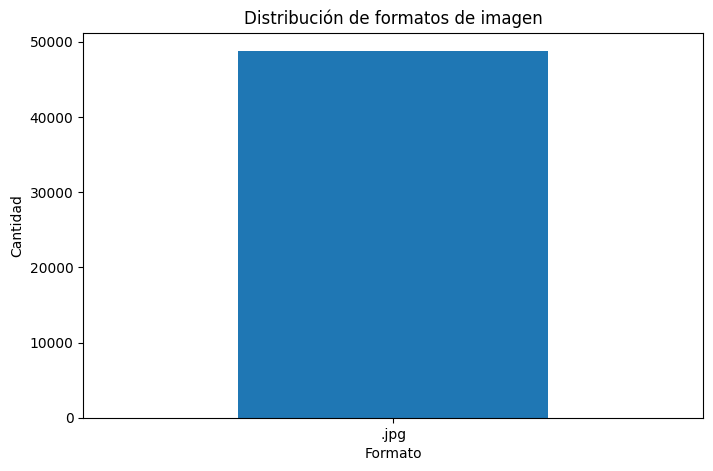

extension
.jpg    48765
Name: count, dtype: int64

In [9]:
#Formato, es 100% jpg, pero lo dejo para que podamos tener un respaldo de que lo hicims para el eda 
format_counts = df["extension"].value_counts()

plt.figure(figsize=(8, 5))
format_counts.plot(kind="bar")
plt.title("Distribución de formatos de imagen")
plt.xlabel("Formato")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

format_counts

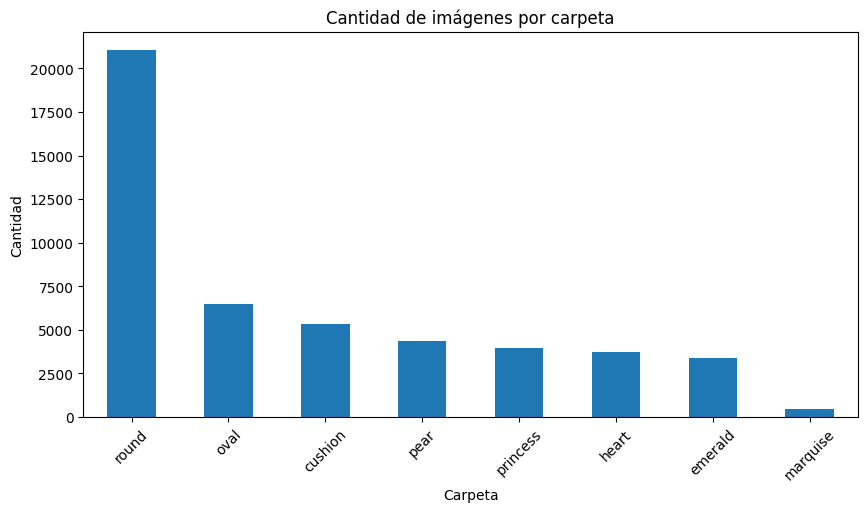

folder
round       21032
oval         6492
cushion      5341
pear         4338
princess     3949
heart        3756
emerald      3392
marquise      465
Name: count, dtype: int64

In [10]:
#Distribucion x carpeta --> Maes importante, se redujo la cantidad de imagenes vs las reales, ya que son mas de 60K y kabre colapsaba,
#hay que subir carpeta por carpeta pero tambien se tarda muchisimo y se llega a saturar, asi que dejo esto como muestra mientras se unifica
#todo y cargamos todo completo 
folder_counts = df["folder"].value_counts()

plt.figure(figsize=(10, 5))
folder_counts.plot(kind="bar")
plt.title("Cantidad de imágenes por carpeta")
plt.xlabel("Carpeta")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.show()

folder_counts

In [11]:
#Deteccion de imagenes da;adas 
metadata = []

for path in tqdm(image_paths):
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode
            
            metadata.append({
                "path": str(path),
                "width": width,
                "height": height,
                "mode": mode,
                "is_corrupt": False
            })
    except Exception:
        metadata.append({
            "path": str(path),
            "width": None,
            "height": None,
            "mode": None,
            "is_corrupt": True
        })

meta_df = pd.DataFrame(metadata)

df = df.merge(meta_df, on="path", how="left")

df.head()

100%|██████████| 48765/48765 [00:19<00:00, 2564.43it/s]


,path,filename,extension,folder,file_size_kb,width,height,mode,is_corrupt
0,/data/ulead-12/Proyecto/kagglehub_cache/datase...,221200-326.jpg,.jpg,oval,33.836914,600.0,471.0,RGB,False
1,/data/ulead-12/Proyecto/kagglehub_cache/datase...,2095495.jpg,.jpg,oval,33.302734,600.0,471.0,RGB,False
2,/data/ulead-12/Proyecto/kagglehub_cache/datase...,212267-349.jpg,.jpg,oval,34.367188,600.0,475.0,RGB,False
3,/data/ulead-12/Proyecto/kagglehub_cache/datase...,2044103.jpg,.jpg,oval,30.926758,600.0,473.0,RGB,False
4,/data/ulead-12/Proyecto/kagglehub_cache/datase...,220123-124.jpg,.jpg,oval,33.173828,600.0,472.0,RGB,False


In [12]:
corrupt_count = df["is_corrupt"].sum()
total_images = len(df)

print("Imágenes corruptas:", corrupt_count)
print("Porcentaje corrupto:", round((corrupt_count / total_images) * 100, 2), "%")

df[df["is_corrupt"] == True]

Imágenes corruptas: 1
Porcentaje corrupto: 0.0 %


,path,filename,extension,folder,file_size_kb,width,height,mode,is_corrupt
44169,/data/ulead-12/Proyecto/kagglehub_cache/datase...,220188-630.jpg,.jpg,emerald,0.22168,NaN,NaN,None,True


In [13]:
#Analisis de tama;o 
valid_df = df[df["is_corrupt"] == False].copy()

valid_df["aspect_ratio"] = valid_df["width"] / valid_df["height"]

valid_df[["width", "height", "aspect_ratio", "file_size_kb"]].describe()

,width,height,aspect_ratio,file_size_kb
count,48764.000000,48764.000000,48764.000000,48764.000000
mean,587.022147,463.239993,1.267741,66.395847
std,26.752755,23.891232,0.021255,50.797795
min,491.000000,381.000000,1.000000,17.773438
25%,591.000000,467.000000,1.265823,33.765625
50%,600.000000,472.000000,1.270732,37.743164
75%,600.000000,474.000000,1.272289,127.559082
max,601.000000,600.000000,1.318605,276.526367


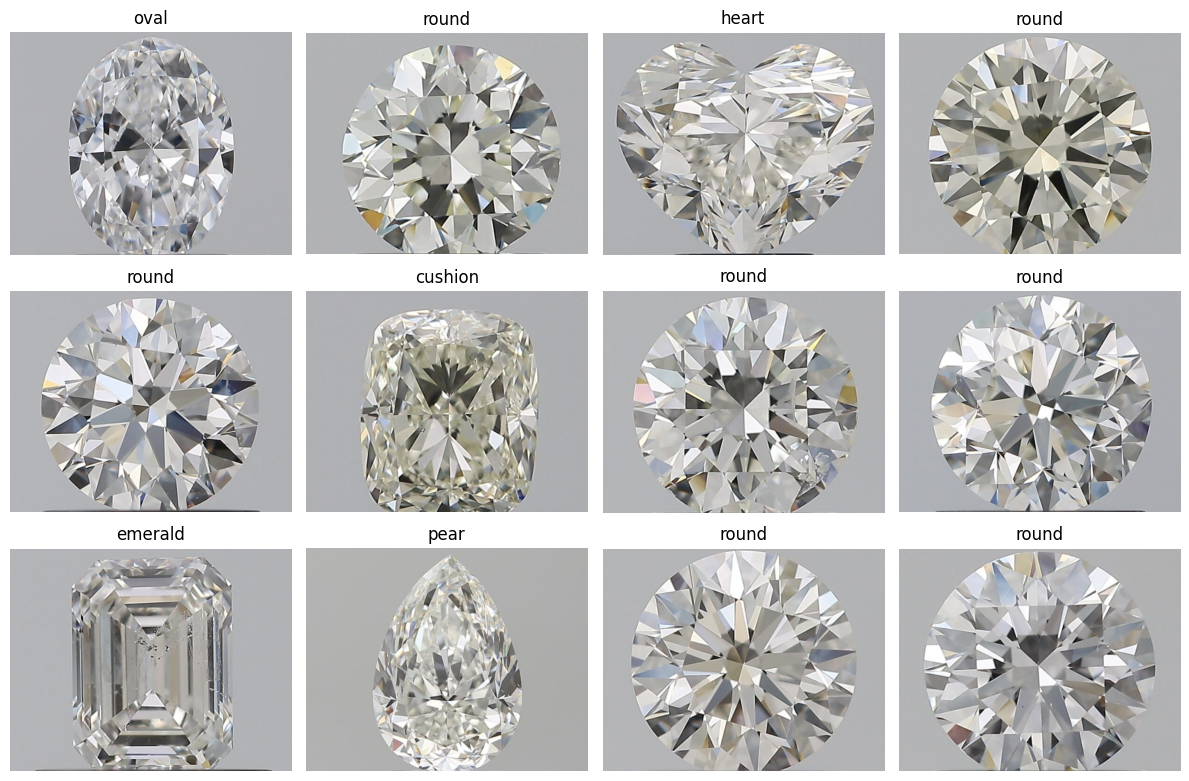

In [14]:
#Muestreo de imagenes 
sample_images = valid_df.sample(min(12, len(valid_df)), random_state=42)

plt.figure(figsize=(12, 8))

for i, row in enumerate(sample_images.itertuples(), 1):
    img = Image.open(row.path)
    plt.subplot(3, 4, i)
    plt.imshow(img)
    plt.title(row.folder)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
brightness_data = []

for path in tqdm(valid_df["path"]):
    img = Image.open(path).convert("L")
    stat = ImageStat.Stat(img)
    
    brightness_data.append({
        "path": path,
        "brightness": stat.mean[0],
        "contrast": stat.stddev[0]
    })

brightness_df = pd.DataFrame(brightness_data)

valid_df = valid_df.merge(brightness_df, on="path", how="left")

valid_df[["brightness", "contrast"]].describe()

100%|██████████| 48764/48764 [02:08<00:00, 380.52it/s]


,brightness,contrast
count,48764.000000,48764.000000
mean,170.852366,37.285362
std,5.853395,6.553444
min,107.652761,12.013631
25%,167.785350,32.834644
50%,171.273287,37.842412
75%,174.112784,41.647388
max,226.170600,72.664141


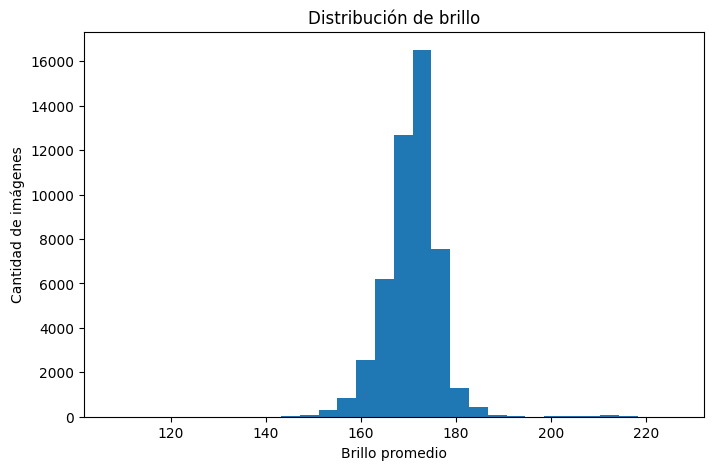

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(valid_df["brightness"], bins=30)
plt.title("Distribución de brillo")
plt.xlabel("Brillo promedio")
plt.ylabel("Cantidad de imágenes")
plt.show()

In [17]:
blur_scores = []

for path in tqdm(valid_df["path"]):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None:
        blur_score = cv2.Laplacian(img, cv2.CV_64F).var()
    else:
        blur_score = None
    
    blur_scores.append({
        "path": path,
        "blur_score": blur_score
    })

blur_df = pd.DataFrame(blur_scores)

valid_df = valid_df.merge(blur_df, on="path", how="left")

valid_df["blur_score"].describe()

100%|██████████| 48764/48764 [02:21<00:00, 345.44it/s]


count    48764.000000
mean       415.266702
std        172.097486
min         30.521694
25%        308.529898
50%        395.024482
75%        494.996276
max       1492.758495
Name: blur_score, dtype: float64

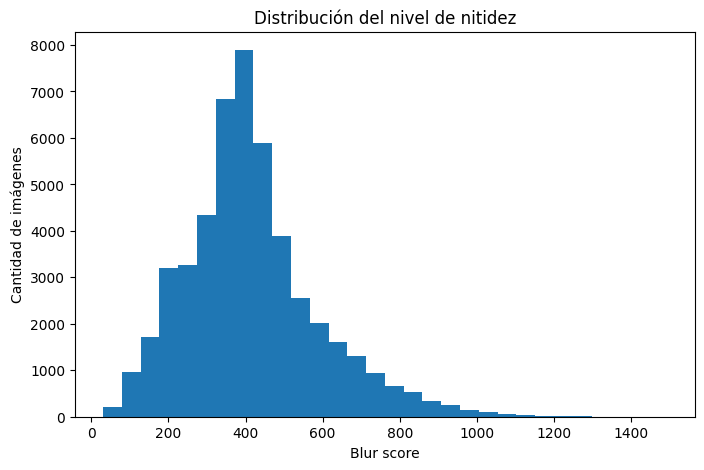

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(valid_df["blur_score"].dropna(), bins=30)
plt.title("Distribución del nivel de nitidez")
plt.xlabel("Blur score")
plt.ylabel("Cantidad de imágenes")
plt.show()

In [19]:
def get_file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

valid_df["file_hash"] = valid_df["path"].apply(get_file_hash)

duplicate_count = valid_df.duplicated("file_hash").sum()

print("Imágenes duplicadas exactas:", duplicate_count)

valid_df[valid_df.duplicated("file_hash", keep=False)].sort_values("file_hash").head()

Imágenes duplicadas exactas: 0


,path,filename,extension,folder,file_size_kb,width,height,mode,is_corrupt,aspect_ratio,brightness,contrast,blur_score,file_hash


In [33]:
#Resultados
OUTPUT_PATH = PROJECT_PATH / "outputs"
OUTPUT_PATH.mkdir(exist_ok=True)

valid_df.to_csv(OUTPUT_PATH / "eda_diamantes_resumen.csv", index=False)

print("Archivo guardado en:", OUTPUT_PATH / "eda_diamantes_resumen.csv")

Archivo guardado en: /home/ulead-12/Proyecto/outputs/eda_diamantes_resumen.csv


In [20]:
total_images_valid = len(valid_df)
total_corrupt = df["is_corrupt"].sum()
total_duplicates = valid_df.duplicated("file_hash").sum()

avg_width = valid_df["width"].mean()
avg_height = valid_df["height"].mean()
avg_brightness = valid_df["brightness"].mean()
avg_contrast = valid_df["contrast"].mean()
avg_blur = valid_df["blur_score"].mean()

print("Resumen del EDA")
print("----------------")
print(f"Total de imágenes válidas: {total_images_valid}")
print(f"Imágenes corruptas: {total_corrupt}")
print(f"Duplicados exactos: {total_duplicates}")
print(f"Tamaño promedio: {avg_width:.2f} x {avg_height:.2f}")
print(f"Brillo promedio: {avg_brightness:.2f}")
print(f"Contraste promedio: {avg_contrast:.2f}")
print(f"Nitidez promedio: {avg_blur:.2f}")

Resumen del EDA
----------------
Total de imágenes válidas: 48764
Imágenes corruptas: 1
Duplicados exactos: 0
Tamaño promedio: 587.02 x 463.24
Brillo promedio: 170.85
Contraste promedio: 37.29
Nitidez promedio: 415.27
